<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/Computer_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTALLAZIONE

In [65]:
!pip install timm -q

IMPORT DELLE LIBRERIE

In [27]:
import os
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

import timm

from sklearn.metrics import classification_report, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

SEED E DISPOSITIVO

In [28]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo utilizzato: {device}")

Dispositivo utilizzato: cuda


DOWNLOAD E DECOMPRESSIONE DEL DATASET

In [29]:
DATASET_ARCHIVE = "progetto-finale-flowes.tar.gz"

if not os.path.exists(DATASET_ARCHIVE):
    !wget -q https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz

if not os.path.exists("progetto-finale-flowes"):
    !tar -xf progetto-finale-flowes.tar.gz

print("Dataset pronto.")

Dataset pronto.


DEFINIZIONE DELLE CARTELLE

In [30]:
data_dir = "progetto-finale-flowes/flowers"

if not os.path.exists(os.path.join(data_dir, "train")):
    data_dir = "progetto-finale-flowes"

if not os.path.exists(os.path.join(data_dir, "train")):
    raise FileNotFoundError("Cartella train non trovata.")

# Check for validation directory
if os.path.exists(os.path.join(data_dir, "val")):
    val_dir_name = "val"
elif os.path.exists(os.path.join(data_dir, "validation")):
    val_dir_name = "validation"
else:
    # If no explicit validation directory is found, use the test directory as a fallback
    # This might not be ideal for true validation, but allows the code to run
    # The user might need to create a proper validation split from the training data if needed.
    val_dir_name = "test"
    print("AVVISO: Cartella di validazione non trovata. Verrà utilizzata la cartella 'test' per la validazione.")


train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, val_dir_name) # Use the determined val_dir_name
test_dir = os.path.join(data_dir, "test")

print(f"Train: {train_dir}")
print(f"Validation: {val_dir}")
print(f"Test: {test_dir}")

AVVISO: Cartella di validazione non trovata. Verrà utilizzata la cartella 'test' per la validazione.
Train: progetto-finale-flowes/train
Validation: progetto-finale-flowes/test
Test: progetto-finale-flowes/test


DATA AUGMENTATION

In [66]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

CREAZIONE DEL DATASET

In [48]:
def is_valid_file(path):
    return (
        not os.path.basename(path).startswith("._")
        and path.lower().endswith((".jpg", ".jpeg", ".png"))
    )


train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms,
    is_valid_file=is_valid_file
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transforms,
    is_valid_file=is_valid_file
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms,
    is_valid_file=is_valid_file
)

class_names = train_dataset.classes

print(f"Classi: {class_names}")
print(f"Immagini Training: {len(train_dataset)}")
print(f"Immagini Validation: {len(val_dataset)}")
print(f"Immagini Test: {len(test_dataset)}")

Classi: ['daisy', 'dandelion']
Immagini Training: 1275
Immagini Validation: 182
Immagini Test: 182


DATALOADER

In [49]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

ResNet18 pretrained e sostituzione dell'ultimo strato

In [50]:
model = timm.create_model(
    "resnet18",
    pretrained=True
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(class_names)
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [67]:
# This cell was redundantly re-initializing model.fc to CPU, causing a device mismatch error.
# The model.fc is correctly initialized and moved to device in cell yf2JFgyMNJmE.
# model.fc = nn.Linear(
#     num_features,
#     len(class_names)
# )

EarlyStopping

In [51]:
class EarlyStopping:

    def __init__(self, patience=3, path="best_flower_model.pth"):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_f1, model):

        if self.best_score is None or val_f1 > self.best_score:

            self.best_score = val_f1
            self.counter = 0

            torch.save(
                model.state_dict(),
                self.path
            )

            print(
                f"   Nuovo best Val F1-Macro: "
                f"{val_f1:.4f} -> pesi salvati"
            )

        else:

            self.counter += 1

            print(
                f"   Nessun miglioramento: "
                f"{self.counter}/{self.patience}"
            )

            if self.counter >= self.patience:
                self.early_stop = True

In [25]:
# This line was causing a NameError and is redundant as EarlyStopping handles saving.

In [68]:
# This line is redundant as EarlyStopping handles saving the model state.

FUNZIONE DI TRAINING

In [69]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    for inputs, labels in dataloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(dataloader.dataset)

FUNZIONE DI VALIDATION

In [70]:
def validate_one_epoch(model, dataloader, device):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for inputs, labels in dataloader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_targets.extend(
                labels.cpu().numpy()
            )

    f1_macro = f1_score(
        all_targets,
        all_preds,
        average="macro"
    )

    return f1_macro

PARAMETRI DI ADDESTRAMENTO

In [71]:
EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
ES_PATIENCE = 3

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

early_stopping = EarlyStopping(
    patience=ES_PATIENCE,
    path="best_flower_model.pth"
)

ADDESTRAMENTO

In [ ]:
train_losses = []
val_f1_scores = []

print("\n--- Inizio Addestramento ---")

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_f1_macro = validate_one_epoch(
        model,
        val_loader,
        device
    )

    train_losses.append(train_loss)
    val_f1_scores.append(val_f1_macro)

    print(
        f"\nEpoca [{epoch + 1}/{EPOCHS}] "
        f"- Train Loss: {train_loss:.4f} "
        f"| Val F1-Macro: {val_f1_macro:.4f}"
    )

    early_stopping(
        val_f1_macro,
        model
    )

    if early_stopping.early_stop:

        print(
            "\n--> Early Stopping attivato."
        )

        break


--- Inizio Addestramento ---

Epoca [1/15] - Train Loss: 0.1595 | Val F1-Macro: 0.9491
   Nuovo best Val F1-Macro: 0.9491 -> pesi salvati

Epoca [2/15] - Train Loss: 0.1406 | Val F1-Macro: 0.9491
   Nessun miglioramento: 1/3

Epoca [3/15] - Train Loss: 0.1635 | Val F1-Macro: 0.9550
   Nuovo best Val F1-Macro: 0.9550 -> pesi salvati

Epoca [4/15] - Train Loss: 0.1340 | Val F1-Macro: 0.9608
   Nuovo best Val F1-Macro: 0.9608 -> pesi salvati


INDIVIDUAZIONE DELLA MIGLIOR EPOCA

In [57]:
best_epoch = np.argmax(val_f1_scores) + 1
best_val_f1 = max(val_f1_scores)

print(f"Best Epoch: {best_epoch}")
print(f"Best Val F1-Macro: {best_val_f1:.4f}")

Best Epoch: 7
Best Val F1-Macro: 0.9491


GRAFICO TRAIN LOSS

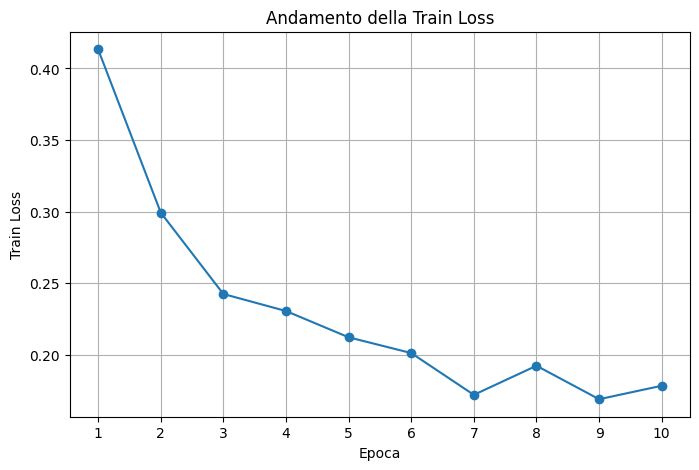

In [56]:
epochs_completed = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_losses,
    marker="o"
)

plt.xlabel("Epoca")
plt.ylabel("Train Loss")
plt.title("Andamento della Train Loss")

plt.xticks(list(epochs_completed))
plt.grid(True)

plt.show()

GRAFICO VALIDATION F-1 MACRO

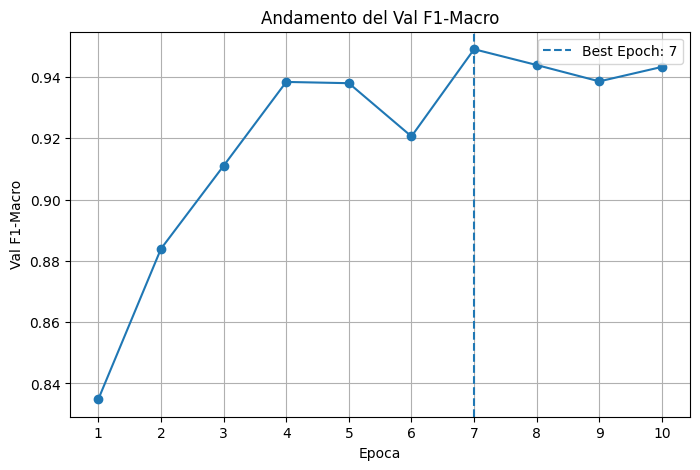

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    val_f1_scores,
    marker="o"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)

plt.xlabel("Epoca")
plt.ylabel("Val F1-Macro")
plt.title("Andamento del Val F1-Macro")

plt.xticks(list(epochs_completed))
plt.grid(True)
plt.legend()

plt.show()

CARICAMENTO DEI PESI MIGLIORI

In [60]:
model.load_state_dict(
    torch.load(
        "best_flower_model.pth",
        map_location=device
    )
)

model.eval()

print("Migliori pesi caricati correttamente.")

Migliori pesi caricati correttamente.


VALUTAZIONE SUL TEST SET

In [61]:
test_targets = []
test_preds = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_targets.extend(
            labels.cpu().numpy()
        )

test_f1_macro = f1_score(
    test_targets,
    test_preds,
    average="macro"
)

print("\n--- Risultato Finale ---")
print(f"Best Epoch: {best_epoch}")
print(f"Best Val F1-Macro: {best_val_f1:.4f}")
print(f"Test F1-Macro: {test_f1_macro:.4f}")


--- Risultato Finale ---
Best Epoch: 7
Best Val F1-Macro: 0.9491
Test F1-Macro: 0.9491


CLASSIFICAZIONE REPORT

In [62]:
print("\n--- Classification Report ---")

print(
    classification_report(
        test_targets,
        test_preds,
        target_names=class_names,
        digits=4
    )
)


--- Classification Report ---
              precision    recall  f1-score   support

       daisy     0.9595    0.9221    0.9404        77
   dandelion     0.9444    0.9714    0.9577       105

    accuracy                         0.9505       182
   macro avg     0.9520    0.9468    0.9491       182
weighted avg     0.9508    0.9505    0.9504       182



CONFUSION MATRIX

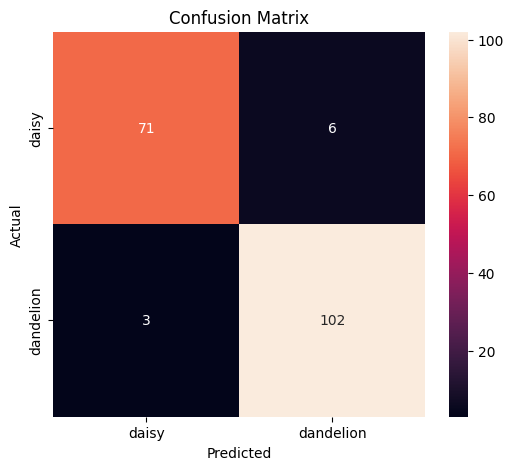

In [63]:
cm = confusion_matrix(
    test_targets,
    test_preds
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

RIEPILOGO FINALE

In [64]:
print("\n==============================")
print("       RISULTATI FINALI")
print("==============================")

print(f"Best Epoch       : {best_epoch}")
print(f"Best Val F1-Macro: {best_val_f1:.4f}")
print(f"Test F1-Macro    : {test_f1_macro:.4f}")

print("==============================")


       RISULTATI FINALI
Best Epoch       : 7
Best Val F1-Macro: 0.9491
Test F1-Macro    : 0.9491
